# Experiment with multilinear fusion model

In [1]:
import sys
import warnings
import math as m
import numpy as np
import pandas as pd
import tensorly as tl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from tqdm import tqdm
import plotly.graph_objs as go

from sklearn.decomposition import PCA, KernelPCA
from statsmodels.tsa.stattools import acf

import scipy
from scipy.linalg import hankel
from scipy.signal import find_peaks
from scipy.spatial import distance_matrix
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.nn.parameter import Parameter
from torch.nn.init import xavier_normal_, xavier_uniform_

sys.path.append('./../')
from tensordynamicmodel.visuals import plot_phase_trajectory, delay_embedding_matrix
from tensordynamicmodel.utils import delay_embedding_matrix, diag_mean, prepare_time_series, lorenz

In [2]:
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams.update({"text.usetex": False})

In [ ]:
class InitPhaseAE(nn.Module):

    def __init__(self, x_dims, rank, attractor_dim):
        super(MultilinearEmbeddingFusion, self).__init__()
        self.x_dims = x_dims
        self.rank = rank
        self.attractor_dim = attractor_dim
        
        self.nn_model_encoder = [
            nn.Sequential(
                nn.Linear(dims, attractor_dim),
                nn.ReLU(),
                nn.Linear(attractor_dim, attractor_dim),
            )
            for dims in x_dims
        ]
        
        self.nn_model_decoder = [
            nn.Sequential(
                nn.Linear(attractor_dim, attractor_dim),
                nn.ReLU(),
                nn.Linear(attractor_dim, dims),
            )
            for dims in x_dims
        ]

        self.x_weights = nn.ParameterList([Parameter(torch.Tensor(self.attractor_dim, self.rank)) for dims in x_dims])
        self.attractor_weights = nn.ParameterList([Parameter(torch.Tensor(self.rank, self.attractor_dim))])
        self.x_weights_out = nn.ParameterList([Parameter(torch.Tensor(attractor_dim, dims)) for dims in x_dims])
        
        _ = [xavier_normal_(x_weight) for x_weight in self.x_weights]
        _ = [xavier_normal_(x_weight) for x_weight in self.attractor_weights]
        _ = [xavier_normal_(x_weight) for x_weight in self.x_weights_out]

    def encoder(self, Xs):
        Hs = [en_model(Xs[i]) for i, en_model in enumerate(self.nn_model_encoder)]
        hidden_Xs = [torch.matmul(Hs[i], x_weight) for i, x_weight in enumerate(self.x_weights)]
        hidden_X = 1
        for i in range(len(self.x_dims)):
            hidden_X *= hidden_Xs[i]
        S = torch.matmul(hidden_X, self.attractor_weights[0])
        return S
    def transform(self, Xs):
        Xs = [torch.from_numpy(X).to(torch.float) for X in Xs]
        return self.encoder(Xs).detach().cpu().numpy()
    
    def decoder(self, S):
        Xs_pred = [de_model(S) for i, de_model in enumerate(self.nn_model_decoder)]
        return Xs_pred
    
    def inverse_transform(self, Xs):
        Xs = [torch.from_numpy(X).to(torch.float) for X in Xs]
        return self.decoder(Xs).detach().cpu().numpy()
        
    def forward(self, Xs):
        S = self.encoder(Xs)
        Xs_pred = self.decoder(S)
        return Xs_pred

In [ ]:
class HiddenPhaseAE(nn.Module):

    def __init__(self, x_dims, rank, attractor_dim):
        super(MultilinearEmbeddingFusion, self).__init__()
        self.x_dims = x_dims
        self.rank = rank
        self.attractor_dim = attractor_dim
        
        self.nn_model_encoder = [
            nn.Sequential(
                nn.Linear(dims, attractor_dim),
                nn.ReLU(),
                nn.Linear(attractor_dim, attractor_dim),
            )
            for dims in x_dims
        ]
        
        self.nn_model_decoder = [
            nn.Sequential(
                nn.Linear(attractor_dim, attractor_dim),
                nn.ReLU(),
                nn.Linear(attractor_dim, dims),
            )
            for dims in x_dims
        ]

        self.x_weights = nn.ParameterList([Parameter(torch.Tensor(self.attractor_dim, self.rank)) for dims in x_dims])
        self.attractor_weights = nn.ParameterList([Parameter(torch.Tensor(self.rank, self.attractor_dim))])
        self.x_weights_out = nn.ParameterList([Parameter(torch.Tensor(attractor_dim, dims)) for dims in x_dims])
        
        _ = [xavier_normal_(x_weight) for x_weight in self.x_weights]
        _ = [xavier_normal_(x_weight) for x_weight in self.attractor_weights]
        _ = [xavier_normal_(x_weight) for x_weight in self.x_weights_out]

    def encoder(self, Xs):
        Hs = [en_model(Xs[i]) for i, en_model in enumerate(self.nn_model_encoder)]
        hidden_Xs = [torch.matmul(Hs[i], x_weight) for i, x_weight in enumerate(self.x_weights)]
        hidden_X = 1
        for i in range(len(self.x_dims)):
            hidden_X *= hidden_Xs[i]
        S = torch.matmul(hidden_X, self.attractor_weights[0])
        return S
    def transform(self, Xs):
        Xs = [torch.from_numpy(X).to(torch.float) for X in Xs]
        return self.encoder(Xs).detach().cpu().numpy()
    
    def decoder(self, S):
        Xs_pred = [de_model(S) for i, de_model in enumerate(self.nn_model_decoder)]
        return Xs_pred
    
    def inverse_transform(self, Xs):
        Xs = [torch.from_numpy(X).to(torch.float) for X in Xs]
        return self.decoder(Xs).detach().cpu().numpy()
        
    def forward(self, Xs):
        S = self.encoder(Xs)
        Xs_pred = self.decoder(S)
        return Xs_pred

In [20]:
class MultilinearEmbeddingFusion(nn.Module):

    def __init__(self, x_dims, rank, attractor_dim):
        super(MultilinearEmbeddingFusion, self).__init__()
        self.x_dims = x_dims
        self.rank = rank
        self.attractor_dim = attractor_dim
        
        self.nn_model_encoder = [
            nn.Sequential(
                nn.Linear(dims, attractor_dim),
                nn.ReLU(),
                nn.Linear(attractor_dim, attractor_dim),
            )
            for dims in x_dims
        ]
        
        self.nn_model_decoder = [
            nn.Sequential(
                nn.Linear(attractor_dim, attractor_dim),
                nn.ReLU(),
                nn.Linear(attractor_dim, dims),
            )
            for dims in x_dims
        ]

        self.x_weights = nn.ParameterList([Parameter(torch.Tensor(self.attractor_dim, self.rank)) for dims in x_dims])
        self.attractor_weights = nn.ParameterList([Parameter(torch.Tensor(self.rank, self.attractor_dim))])
        self.x_weights_out = nn.ParameterList([Parameter(torch.Tensor(attractor_dim, dims)) for dims in x_dims])
        
        _ = [xavier_normal_(x_weight) for x_weight in self.x_weights]
        _ = [xavier_normal_(x_weight) for x_weight in self.attractor_weights]
        _ = [xavier_normal_(x_weight) for x_weight in self.x_weights_out]

    def encoder(self, Xs):
        Hs = [en_model(Xs[i]) for i, en_model in enumerate(self.nn_model_encoder)]
        hidden_Xs = [torch.matmul(Hs[i], x_weight) for i, x_weight in enumerate(self.x_weights)]
        hidden_X = 1
        for i in range(len(self.x_dims)):
            hidden_X *= hidden_Xs[i]
        S = torch.matmul(hidden_X, self.attractor_weights[0])
        return S
    def transform(self, Xs):
        Xs = [torch.from_numpy(X).to(torch.float) for X in Xs]
        return self.encoder(Xs).detach().cpu().numpy()
    
    def decoder(self, S):
        Xs_pred = [de_model(S) for i, de_model in enumerate(self.nn_model_decoder)]
        return Xs_pred
    
    def inverse_transform(self, Xs):
        Xs = [torch.from_numpy(X).to(torch.float) for X in Xs]
        return self.decoder(Xs).detach().cpu().numpy()
        
    def forward(self, Xs):
        S = self.encoder(Xs)
        Xs_pred = self.decoder(S)
        return Xs_pred

In [ ]:
rank = 5
x_dims = [x.shape[1] for x in npa_Xs] 
attractor_dim = 
MultilinearEmbeddingFusion(x_dims, rank, attractor_dim)

In [21]:
def fit_torch_model(npa_Xs, attractor_dim, model):
    optimizer = optim.Adam(model.parameters())
    epoch = 1000 
    loss_function = nn.MSELoss()
    ta_Xs = [torch.from_numpy(x).to(torch.float) for x in npa_Xs]
    for i in range(epoch):
        loss = 0
        optimizer.zero_grad()
        ta_Xs_rec = model(ta_Xs)
        for X, X_rec in zip(ta_Xs, ta_Xs_rec):
            loss += loss_function(X, X_rec)
        loss.backward()
        optimizer.step()
    model.eval()
    return model

In [22]:
def make_ts(person, activity):
    pdf_data_all = pd.read_csv(f'./../data/A_DeviceMotion_data/{activity}/sub_{person}.csv').reset_index(drop=True)
    data_list = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
    # data_list = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z', 'rotationRate.x', 'rotationRate.y', 'rotationRate.z']
    data_list_short = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
    # mean = pdf_data_all[data_list].mean()
    # var = pdf_data_all[data_list].var()**.5
    # pdf_data_all[data_list] = (pdf_data_all[data_list]-mean)/var
    pdf_data_all = pdf_data_all[data_list_short]
    xyz = pdf_data_all[data_list_short].to_numpy()
    x, y, z = xyz[:,0], xyz[:,1], xyz[:,2]
    return x,y,z

In [23]:
def make_experiment_xy_z(activity, lag):
    result_tables_model_names = [
        'person',
        'X',
        'Kernel PCA',
        'Tensor X'
    ]
    pdf_r2_train_ts = pd.DataFrame(columns=result_tables_model_names)
    pdf_mse_train_ts = pd.DataFrame(columns=result_tables_model_names)
    
#     for person in tqdm([1, 2, 4, 5, 6, 7, 8, 9, 11, 12]):
    for person in tqdm([1, 2]):
        
        x, y, z = make_ts(person, activity)
        if x.shape[0] <= 650:
            continue
    
        Xs_tde = [
            delay_embedding_matrix(x, lag, fit_intercept=False)[:,::freq_n],
            delay_embedding_matrix(y, lag, fit_intercept=False)[:,::freq_n],
            delay_embedding_matrix(z, lag, fit_intercept=False)[:,::freq_n]
        ]
        
        for dim_n in  range(2,7):
            _pdf_r2_train_ts = pd.DataFrame(columns=result_tables_model_names)
            _pdf_mse_train_ts = pd.DataFrame(columns=result_tables_model_names)
    
            # Make state space reconstruction models
            list_S = []
            model_init_phase = model = tensor_model_fit_transform(Xs_tde, dim_n)
            model_hidden_phase =
            model_tensor_phase = 
            
            model = tensor_model_fit_transform(Xs_tde, dim_n)
            list_S.append(model.transform([X[:500,:] for X in Xs_tde]))
            
            list_Wx_rec = [np.linalg.inv(S.T@S + l2_coef*np.identity(dim_n))@S.T@X_tde[:500,:] for S in list_S]
            
            # Dim reduction for valid ts
            list_S = [ model.transform(X_tde[500:,:]) for model in list_model]
            list_S.append(model.transform([X[500:,:] for X in Xs_tde]))
        
            # Resore initial time series
            x_rec = [diag_mean(s@w) for s,w in zip(list_S, list_Wx_rec)]
            x_ts = diag_mean(X_tde[500:,:])
            
            _pdf_r2_train_ts.loc[dim_n, :] = [person]+[r2_score(x_ts, x) for x in x_rec]
            _pdf_mse_train_ts.loc[dim_n, :] = [person]+[mse(x_ts, x)**.5 for x in x_rec]

            pdf_r2_train_ts = pd.concat([pdf_r2_train_ts, _pdf_r2_train_ts], axis=0)
            pdf_mse_train_ts = pd.concat([pdf_mse_train_ts, _pdf_mse_train_ts], axis=0)

    return pdf_r2_train_ts, pdf_mse_train_ts

In [26]:
freq_n = 1
l2_coef = 1
list_all_exp = []
list_activities = [
#     'dws_11',
    # 'ups_3', 'wlk_15',
    
    # 'dws_1', 'dws_2',
    # 'jog_16', 'jog_9',
    # 'sit_13', 'sit_5',
    # 'std_14', 'std_6',
    # 'ups_12', 'ups_4',
    'wlk_7',
    # 'wlk_8'.
]

list_all_exp = [make_experiment_xy_z(activity, 15) for activity in list_activities]

100%|█████████████████████████████████████████████| 2/2 [00:37<00:00, 18.89s/it]


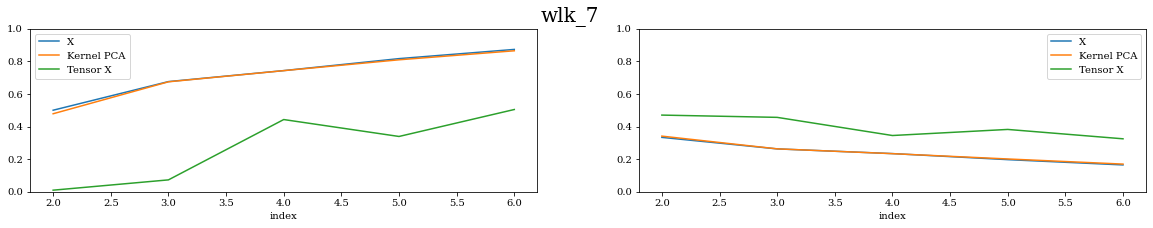

In [27]:
for name, exp_act in zip(list_activities, list_all_exp):
    fig, axs = plt.subplots(1,2,figsize=(20,3))
    _ = [DF.drop(columns=['person']).reset_index().groupby('index').mean().plot(ax=ax) for DF, ax in zip(exp_act, axs)]
    _ = [ax.set_ylim(0,1) for ax in axs]
    fig.suptitle(name, fontsize=20)